# Лабораторная работа 2: Глубокое обучение для компьютерного зрения (FashionMNIST)

[Компьютерное зрение](https://en.wikipedia.org/wiki/Computer_vision) — это искусство научить компьютер видеть.

Например, это может включать в себя создание модели для классификации того, изображена ли на фотографии кошка или собака ([бинарная классификация](https://developers.google.com/machine-learning/glossary#binary-classification)).

Или фотография кошки, собаки или курицы ([многоклассовая классификация](https://developers.google.com/machine-learning/glossary#multi-class-classification)).

Или определение места появления автомобиля в кадре видео ([обнаружение объекта](https://en.wikipedia.org/wiki/Object_detection)).

Или выяснить, где можно разделить разные объекты на изображении ([паноптическая сегментация](https://arxiv.org/abs/1801.00868)).


## О чем мы собираемся рассказать

В лабораторной работе мы применим рабочий процесс глубокого обучения PyTorch к задаче компьютерного зрения для датасета FashionMNIST.

![рабочий процесс PyTorch с упором на компьютерное зрение](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-pytorch-computer-vision-workflow.png)

В частности, мы рассмотрим:

| **Тема** | **Содержание** |
| ----- | ----- |
| **0. Библиотеки компьютерного зрения в PyTorch** | PyTorch имеет множество встроенных полезных библиотек компьютерного зрения, давайте их проверим.  |
| **1. Загрузить данные** | Чтобы попрактиковаться в компьютерном зрении, мы начнем с изображений различных предметов одежды из [FashionMNIST] (https://github.com/zalandoresearch/fashion-mnist). |
| **2. Подготовить данные** | У нас есть несколько изображений, давайте загрузим их с помощью [PyTorch `DataLoader`](https://pytorch.org/docs/stable/data.html), чтобы мы могли использовать их в нашем цикле обучения. |
| **3. Модель 1 (базовая): `FashionMNISTModelV1`** | Нашей основной базой глубокого обучения будет полносвязная нейронная сеть («FashionMNISTModelV1») с нелинейными слоями. |
| **4. Прогнозирование и оценка Модели 1** | Давайте сделаем некоторые прогнозы с помощью нашей базовой модели и оценим их. |
| **5. Настройте независимый код устройства для будущих моделей** | Лучше всего писать код, независимый от устройства, поэтому давайте настроим его. |
| **6. Модель 2: Сверточная нейронная сеть (CNN)** | Затем мы построим сверточную модель («FashionMNISTModelV2») и сравним ее с нашей базовой моделью. |
| **7. Сравнение наших моделей** | Мы сравним обе модели, рассматривая FashionMNISTModelV1 как нашу базовую глубокую модель, а FashionMNISTModelV2 как нашу модель свертки. |
| **8. Оцениваем нашу лучшую модель** | Давайте сделаем некоторые прогнозы на случайных изображениях и оценим нашу лучшую модель. |
| **9. Составление матрицы путаницы** | Матрица путаницы — отличный способ оценить модель классификации. Давайте посмотрим, как ее можно создать. |
| **10. Сохранение и загрузка наиболее эффективной модели** | Поскольку мы, возможно, захотим использовать нашу модель позже, давайте сохраним ее и убедимся, что она загружается правильно. |


## 0. Библиотеки компьютерного зрения в PyTorch

Прежде чем мы начнем писать код, давайте поговорим о некоторых библиотеках компьютерного зрения PyTorch, о которых вам следует знать.

| Модуль PyTorch | Что он делает? |
| ----- | ----- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html) | Содержит наборы данных, архитектуры моделей и преобразования изображений, часто используемые для решения задач компьютерного зрения. |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) | Здесь вы найдете множество примеров наборов данных компьютерного зрения для решения широкого спектра задач: от классификации изображений, обнаружения объектов, субтитров к изображениям, классификации видео и многого другого. Он также содержит [серию базовых классов для создания пользовательских наборов данных](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets). |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html) | Этот модуль содержит хорошо работающие и часто используемые архитектуры моделей компьютерного зрения, реализованные в PyTorch. Вы можете использовать их для решения своих собственных задач. |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) | Часто изображения необходимо преобразовать (превратить в числа/обработать/дополнить) перед использованием в модели. Общие преобразования изображений можно найти здесь. |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Базовый класс набора данных для PyTorch.  |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Создает итерацию Python по набору данных (созданному с помощью `torch.utils.data.Dataset`). |

> **Примечание.** Классы `torch.utils.data.Dataset` и `torch.utils.data.DataLoader` предназначены не только для компьютерного зрения в PyTorch, они способны обрабатывать множество различных типов данных.

Теперь мы рассмотрели некоторые из наиболее важных библиотек компьютерного зрения PyTorch, давайте импортируем соответствующие зависимости.


In [5]:
#Импортировать PyTorch
import torch
from torch import nn

#Импортировать Torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

#Импортируйте matplotlib для визуализации.
import matplotlib.pyplot as plt

#Проверить версии
#Примечание. ваша версия PyTorch не должна быть ниже 1.10.0, а версия torchvision не должна быть ниже 0,11.
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")


PyTorch version: 2.12.0+cpu
torchvision version: 0.27.0+cpu


In [6]:
#Посмотрите, существует ли torchmetrics, если нет, установите его.
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    #!pip install -q torchmetrics -U mlxtend #<- Примечание. Если вы используете Google Colab, может потребоваться перезапуск среды выполнения.
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")


mlxtend version: 0.24.0


## 1. Получение набора данных

Чтобы начать работу над задачей компьютерного зрения, давайте импортируем набор данных.

Мы собираемся начать с FashionMNIST.

MNIST означает «Модифицированный национальный институт стандартов и технологий».

[Исходный набор данных MNIST] (https://en.wikipedia.org/wiki/MNIST_database) содержит тысячи примеров рукописных цифр (от 0 до 9) и использовался для построения моделей компьютерного зрения для определения номеров почтовых служб.

[FashionMNIST](https://github.com/zalandoresearch/fashion-mnist), созданный Zalando Research, представляет собой аналогичную схему.

За исключением того, что он содержит изображения 10 различных видов одежды в оттенках серого.

![пример изображения FashionMNIST](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-fashion-mnist-slide.png)
*`torchvision.datasets` содержит множество примеров наборов данных, которые вы можете использовать для практики написания кода для компьютерного зрения. FashionMNIST — один из таких наборов данных. А поскольку у него 10 различных классов изображений (разные типы одежды), это проблема классификации нескольких классов.*

Позже мы создадим нейронную сеть, чтобы идентифицировать различные стили одежды на этих изображениях.

PyTorch имеет набор распространенных наборов данных компьютерного зрения, хранящихся в файле torchvision.datasets.

Включение FashionMNIST в [`torchvision.datasets.FashionMNIST()`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html).

Для его загрузки мы предоставляем следующие параметры:
* `root:str` — в какую папку вы хотите загрузить данные?
* `train` (bool) – вы хотите разделить обучение или тестирование?
* `download:Bool` — нужно ли скачивать данные?
* `transform: torchvision.transforms` — какие преобразования вы хотели бы выполнить с данными?
* `target_transform` — вы также можете трансформировать цели (метки), если хотите.

Многие другие наборы данных в torchvision имеют такие параметры.


In [7]:
#Настройка данных обучения
train_data = datasets.FashionMNIST(
    root="data", #куда скачать данные?
    train=True, #получить данные обучения
    download=True, #загрузить данные, если их нет на диске
    transform=ToTensor(), #изображения поступают в формате PIL, мы хотим превратить их в тензоры Torch.
    target_transform=None #вы также можете трансформировать ярлыки
)

#Данные тестирования настройки
test_data = datasets.FashionMNIST(
    root="data",
    train=False, #получить тестовые данные
    download=True,
    transform=ToTensor()
)


Давайте проверим первый сэмпл из обучающей выборки.


In [8]:
#См. первый обучающий образец
image, label = train_data[0]
image, label


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

### 1.1 Входные и выходные формы модели компьютерного зрения

У нас есть большой тензор значений (изображение), ведущий к одному значению для метки класса.

Давайте посмотрим на форму изображения.


In [9]:
#Какова форма изображения?
image.shape


torch.Size([1, 28, 28])

Форма тензора изображения — `[1, 28, 28]` или, точнее:

```
[color_channels=1, высота=28, ширина=28]
```

Наличие `color_channels=1` означает, что изображение имеет оттенки серого.

![пример входных и выходных форм задачи fashionMNIST](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-computer-vision-input-and-output-shapes.png)
*Различные задачи будут иметь разные формы ввода и вывода. Но предпосылка остается: закодируйте данные в числа, постройте модель для поиска закономерностей в этих числах, преобразуйте эти закономерности во что-то значимое.*

Если `color_channels=3`, изображение имеет значения красного, зеленого и синего пикселей в пикселях (это также известно как [цветовая модель RGB] (https://en.wikipedia.org/wiki/RGB_color_model)).

Порядок нашего текущего тензора часто называют CHW (цветовые каналы, высота, ширина).

Ведутся споры о том, следует ли представлять изображения как «CHW» (цветовые каналы первыми) или «HWC» (цветовые каналы последними).

> **Примечание.** Вы также увидите форматы `NCHW` и `NHWC`, где `N` означает *количество изображений*. Например, если у вас есть `batch_size=32`, ваша форма тензора может быть `[32, 1, 28, 28]`. О размерах партий мы поговорим позже.

PyTorch обычно принимает NCHW (сначала каналы) в качестве значения по умолчанию для многих операторов.

Однако PyTorch также объясняет, что NHWC (последние каналы) работает лучше и [считается лучшей практикой] (https://pytorch.org/blog/tensor-memory-format-matters/#pytorch-best-practice).

На данный момент, поскольку наш набор данных и модели относительно невелики, это не будет иметь большого значения.

Давайте проверим больше форм наших данных.


In [10]:
#Сколько образцов имеется?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)


(60000, 60000, 10000, 10000)

Итак, у нас есть 60 000 обучающих и 10 000 тестовых образцов.

Какие классы есть?

Мы можем найти их через атрибут .classes.


In [11]:
#Посмотреть классы
class_names = train_data.classes
class_names


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Поскольку мы работаем с 10 различными классами, это означает, что наша проблема — **классификация по нескольким классам**.


### 1.2 Визуализация наших данных


Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

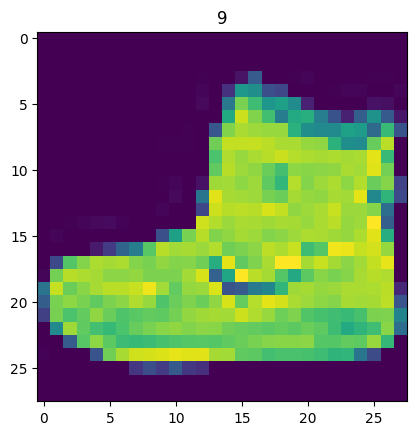

In [12]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) #форма изображения — [1, 28, 28] (цветовые каналы, высота, ширина)
plt.title(label)


Мы можем превратить изображение в оттенки серого, используя параметр cmap функции plt.imshow().


Text(0.5, 1.0, 'Ankle boot')

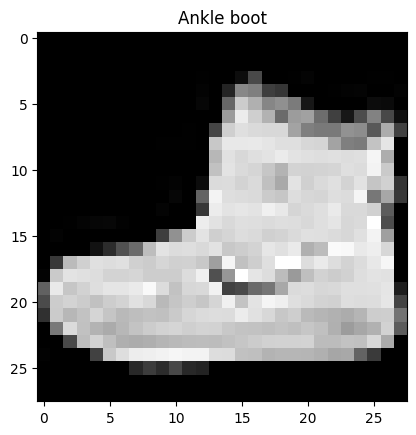

In [13]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])


Давайте посмотрим еще несколько.


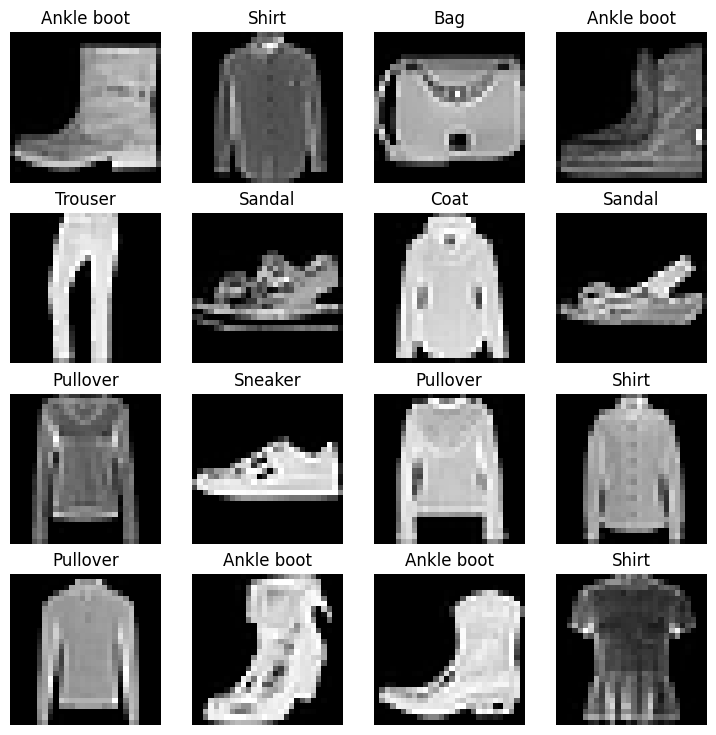

In [14]:
#Нарисуйте больше изображений
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)


Принципы построения модели, которые мы собираемся изучить, будут одинаковыми для широкого спектра задач компьютерного зрения.

По сути, мы берем значения пикселей и создаем модель, чтобы найти в них шаблоны для использования в будущих значениях пикселей.

Кроме того, даже для этого небольшого набора данных (да, даже 60 000 изображений при глубоком обучении считаются довольно небольшими) можете ли вы написать программу, классифицирующую каждое из них?

Вы, наверное, могли бы.

Но я думаю, что кодирование модели в PyTorch будет быстрее.

> **Вопрос:** Считаете ли вы, что приведенные выше данные можно моделировать только с помощью прямых (линейных) линий? Или вы думаете, что вам также понадобятся непрямые (нелинейные) линии?


## 2. Подготовьте загрузчик данных

Следующий шаг — подготовить его с помощью [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) или для краткости `DataLoader`.

DataLoader делает то, что вы думаете (44 группа, привет Софье Владимировне))).

Это помогает загрузить данные в модель.

Для обучения и вывода.

Он превращает большой набор данных в Python, состоящий из более мелких фрагментов.

Эти меньшие фрагменты называются **пакетами** или **мини-пакетами** и могут быть установлены параметром `batch_size`.

Зачем это делать?

Потому что это более эффективно в вычислительном отношении.

В идеальном мире вы могли бы выполнить прямой и обратный проход по всем вашим данным одновременно.

Но как только вы начнете использовать действительно большие наборы данных, если у вас нет бесконечной вычислительной мощности, их будет легче разбить на пакеты.

Это также дает вашей модели больше возможностей для улучшения.

При использовании **мини-пакетов** (небольших частей данных) градиентный спуск выполняется чаще за эпоху (один раз за мини-пакет, а не один раз за эпоху).

Каков хороший размер партии?

[32 — хорошее место для начала](https://twitter.com/ylecun/status/989610208497360896?s=20&t=N96J_jotN--PYuJk2WcjMw) для решения большого количества задач.

Но поскольку это значение, которое вы можете установить (**гиперпараметр**), вы можете попробовать разные типы значений, хотя обычно чаще всего используются степени 2 (например, 32, 64, 128, 256, 512).

![пример того, как выглядит пакетный набор данных](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-batching-fashionmnist.png)
* Пакетная обработка FashionMNIST с размером пакета 32 и включенным перемешиванием. Аналогичный процесс пакетной обработки будет происходить и для других наборов данных, но будет отличаться в зависимости от размера пакета.*

Давайте создадим DataLoader для наших обучающих и тестовых наборов.


In [15]:
from torch.utils.data import DataLoader

#Настройте гиперпараметр размера пакета
BATCH_SIZE = 32

#Превратите наборы данных в итерации (пакеты)
train_dataloader = DataLoader(train_data, #набор данных, который нужно превратить в итерируемый
    batch_size=BATCH_SIZE, # сколько образцов в пакете?
    shuffle=True # перетасовывать данные каждую эпоху?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # не обязательно перемешивать данные тестовой выборки
)

# Давайте проверим, что мы создали
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")


Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001F94BD52BA0>, <torch.utils.data.dataloader.DataLoader object at 0x000001F94FB56850>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [16]:
# Посмотрите, что находится внутри загрузчика обучающих данных
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [17]:
# Вы можете использовать его для проверки пакета
#для train_features_batch, train_labels_batch в iter(test_dataloader):
#print(train_features_batch.shape, train_labels_batch.shape)


И мы видим, что данные остаются неизменными, проверив один образец.


Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

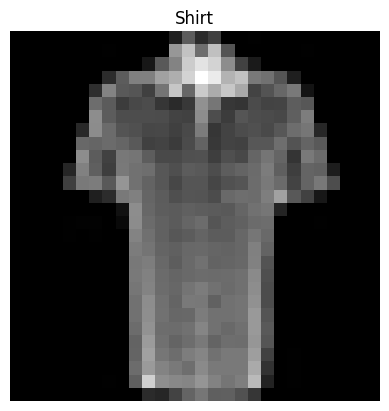

In [18]:
# Показать образец
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off")


## 3. Модель: постройте базовую модель.

Данные загружены и подготовлены!


Слой `nn.Flatten()` принял нашу форму от `[color_channels, height, width]` до `[color_channels, height*width]`.

Зачем это делать?

Потому что теперь мы превратили наши пиксельные данные из размеров высоты и ширины в один длинный **вектор объектов**.

А слоям nn.Linear() нравится, чтобы их входные данные были в виде векторов объектов.

Давайте создадим нашу первую модель, используя nn.Flatten() в качестве первого слоя.


In [19]:
# Создайте модель с нелинейными и линейными слоями.
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # свести входные данные в один вектор
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)


У нас есть класс базовой модели, который мы можем использовать, теперь давайте создадим экземпляр модели.

Нам нужно будет установить следующие параметры:
* `input_shape=784` — это количество функций, которые вы используете в модели, в нашем случае это по одному на каждый пиксель целевого изображения (28 пикселей в высоту и 28 пикселей в ширину = 784 объекта).
* `hidden_units=10` — количество единиц/нейронов в скрытом слое(ях), это число может быть любым, но чтобы модель была маленькой, мы начнём с `10`.
* `output_shape=len(class_names)` — поскольку мы работаем с проблемой классификации нескольких классов, нам нужен выходной нейрон для каждого класса в нашем наборе данных.

Давайте сейчас создадим экземпляр нашей модели и отправим его в ЦП (скоро мы проведем небольшой тест для запуска «модели 1» на ЦП и аналогичной модели на графическом процессоре).


In [20]:
torch.manual_seed(42)

# Необходимо настроить модель с входными параметрами
model1 = FashionMNISTModelV1(input_shape=784, #по одному на каждый пиксель (28x28)
    hidden_units=10, # сколько единиц в скрытом слое
    output_shape=len(class_names) # по одному на каждый класс
)
model1.to("cpu") # для начала оставьте модель на процессоре CPU


FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

### 3.1 Потери при настройке, оптимизатор и метрики оценки
Мы собираемся написать собственную функцию точности, чтобы проверять точность нашей модели.


In [21]:
# Вычисление точности (показатель точности классификации)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


In [22]:
# Настройка функции потерь и оптимизатора
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model1.parameters(), lr=0.1)


### 3.2 Создание функции для измерения времени наших экспериментов

Пришло время приступить к обучению модели.

Но как насчет того, чтобы провести небольшой эксперимент во время тренировки?

Я имею в виду, давайте создадим функцию времени, чтобы измерить время, необходимое нашей модели для обучения на процессоре, а не на графическом процессоре.

Мы обучим эту модель на ЦП, а следующую — на графическом процессоре и посмотрим, что произойдет.

Наша функция синхронизации импортирует [`timeit.default_timer()`](https://docs.python.org/3/library/timeit.html#timeit.default_timer) из Python [`timeit` модуль](https://docs.python.org/3/library/timeit.html).


In [23]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time


### 3.3 Создание цикла обучения и обучение модели на пакетах данных

Похоже, у нас есть все части головоломки, готовые к работе: таймер, функция потерь, оптимизатор, модель и, самое главное, некоторые данные.

Давайте теперь создадим цикл обучения и цикл тестирования для обучения и оценки нашей модели.

Мы будем использовать те же шаги, что и в предыдущих блокнотах, однако, поскольку наши данные теперь находятся в пакетной форме, мы добавим еще один цикл для перебора наших пакетов данных.

Наши пакеты данных содержатся в наших DataLoader, train_dataloader и test_dataloader для разделения обучающих и тестовых данных соответственно.

Пакет представляет собой образцы «BATCH_SIZE» из «X» (функций) и «y» (меток), поскольку мы используем «BATCH_SIZE=32», наши пакеты содержат 32 образца изображений и целей.

А поскольку мы выполняем вычисления на пакетах данных, наши показатели потерь и оценки будут рассчитываться **для каждого пакета**, а не для всего набора данных.

Это означает, что нам придется разделить наши значения потерь и точности на количество пакетов в соответствующем загрузчике данных каждого набора данных.

Давайте пройдемся по этому этапу:
1. Перебирать эпохи.
2. Пройдитесь по обучающим пакетам, выполните шаги обучения, рассчитайте потери поездов *на пакет*.
3. Переберите тестовые партии, выполните этапы тестирования, рассчитайте потери при тестировании *на партию*.
4. Распечатайте происходящее.
5. Засеките время (для развлечения).


In [24]:
#Импортировать tqdm для индикатора выполнения
from tqdm.auto import tqdm

#Установите семя и запустите таймер
torch.manual_seed(42)
train_time_start_on_cpu = timer()

#Установите количество эпох (мы оставим его небольшим для более быстрого обучения)
epochs = 3

#Создайте цикл обучения и тестирования
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Обучение
    train_loss = 0
    #Добавьте цикл для прохождения обучающих пакетов.
    for batch, (X, y) in enumerate(train_dataloader):
        model1.train()
        #1. Пас вперед
        y_pred = model1(X)

        #2. Рассчитать потери (на партию)
        loss = loss_fn(y_pred, y)
        train_loss += loss #кумулятивно складывать потери за эпоху

        #3. Оптимизатор нулевой градации
        optimizer.zero_grad()

        #4. Проигрыш назад
        loss.backward()

        #5. Шаг оптимизатора
        optimizer.step()

        #Распечатайте, сколько образцов было просмотрено
        if batch % 400 == 0:
            print(f"Trained on {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    #Разделите общие потери поезда на длину загрузчика данных поезда (средние потери на партию за эпоху)
    train_loss /= len(train_dataloader)

    ### Тестирование
    #Настройте переменные для кумулятивного суммирования потерь и точности.
    test_loss, test_acc = 0, 0
    model1.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            #1. Пас вперед
            test_pred = model1(X)

            #2. Рассчитать потери (нарастающим итогом)
            test_loss += loss_fn(test_pred, y) #кумулятивно складывать потери за эпоху

            #3. Рассчитайте точность (преды должны быть такими же, как y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        #Расчеты тестовых показателей должны происходить внутри torch.inference_mode().
        #Разделите общие потери при тестировании на длину загрузчика тестовых данных (на партию)
        test_loss /= len(test_dataloader)

        #Разделите общую точность на длину загрузчика тестовых данных (на партию)
        test_acc /= len(test_dataloader)

    ## Распечатать, что происходит
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

#Рассчитать время обучения
train_time_end_on_cpu = timer()
total_train_time_model1 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model1.parameters()).device))


c:\Users\aukvary\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Trained on 0/60000 samples
Trained on 12800/60000 samples
Trained on 25600/60000 samples
Trained on 38400/60000 samples
Trained on 51200/60000 samples


 33%|███▎      | 1/3 [00:08<00:16,  8.43s/it]


Train loss: 1.09199 | Test loss: 0.95636, Test acc: 65.00%

Epoch: 1
-------
Trained on 0/60000 samples
Trained on 12800/60000 samples
Trained on 25600/60000 samples
Trained on 38400/60000 samples
Trained on 51200/60000 samples


 67%|██████▋   | 2/3 [00:16<00:08,  8.12s/it]


Train loss: 0.78101 | Test loss: 0.72227, Test acc: 73.91%

Epoch: 2
-------
Trained on 0/60000 samples
Trained on 12800/60000 samples
Trained on 25600/60000 samples
Trained on 38400/60000 samples
Trained on 51200/60000 samples


100%|██████████| 3/3 [00:22<00:00,  7.62s/it]


Train loss: 0.67027 | Test loss: 0.68500, Test acc: 75.02%

Train time on cpu: 22.856 seconds


Похоже, наша базовая модель показала себя неплохо.

Обучение тоже не заняло много времени, даже только на ЦП, интересно, ускорится ли на ГП?

Давайте напишем код для оценки нашей модели.


## 4. Делайте прогнозы и получайте результаты модели

Поскольку мы собираемся построить несколько моделей, хорошей идеей будет написать код, который будет оценивать их все одинаковым образом.

А именно, давайте создадим функцию, которая принимает обученную модель, DataLoader, функцию потерь и функцию точности.

Функция будет использовать модель для прогнозирования данных в DataLoader, а затем мы сможем оценить эти прогнозы, используя функцию потерь и функцию точности.


In [25]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = None):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (torch.device, optional): Target device. If None, inferred from the model.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    if device is None:
        device = next(model.parameters()).device
    with torch.inference_mode():
        for X, y in data_loader:
            #Отправка данных на то же устройство, что и модель
            X, y = X.to(device), y.to(device)
            #Делайте прогнозы с помощью модели
            y_pred = model(X)

            #Накопите значения потерь и точности для каждой партии.
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) #Для точности нужны метки прогнозирования (logits -> pred_prob -> pred_labels)

        #Масштабируйте потери и акк, чтобы найти средние потери/акк на партию.
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, #работает только тогда, когда модель была создана с классом
            "model_loss": loss.item(),
            "model_acc": acc}

#Рассчитать результаты модели 0 в наборе тестовых данных
model1_results = eval_model(model=model1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model1_results


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

Выглядишь хорошо!

Мы можем использовать этот словарь для сравнения результатов базовой модели с другими моделями позже.


## 5. Установите код, независимый от устройства (для использования графического процессора, если он есть)
Мы видели, сколько времени требуется для обучения модели PyTorch на 60 000 выборках на ЦП.

> **Примечание.** Время обучения модели зависит от используемого оборудования. Как правило, большее количество процессоров означает более быстрое обучение, а модели меньшего размера на меньших наборах данных часто обучаются быстрее, чем большие модели и большие наборы данных.

Теперь давайте настроим некоторый [код, независимый от устройства] (https://pytorch.org/docs/stable/notes/cuda.html#best-practices) для запуска наших моделей и данных на графическом процессоре, если он доступен.

Если вы используете этот ноутбук в Google Colab и у вас еще не включен графический процессор, самое время включить его через «Среда выполнения -> Изменить тип среды выполнения -> Аппаратный ускоритель -> Графический процессор». Если вы это сделаете, ваша среда выполнения, скорее всего, будет сброшена, и вам придется запустить все ячейки, указанные выше, выбрав «Время выполнения -> Выполнить все».


In [26]:
#Код настройки устройства
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

Красивый!

Давайте построим еще одну модель.


## 6. Модель 2: построение той же модели с использованием графического процессора


In [27]:
torch.manual_seed(42)
model2 = FashionMNISTModelV1(input_shape=784, #количество входных функций
    hidden_units=10,
    output_shape=len(class_names) #желаемое количество выходных классов
).to(device) #отправьте модель в графический процессор, если она доступна
next(model2.parameters()).device #проверить модель устройства


device(type='cpu')

### 6.1 Потери при настройке, оптимизатор и метрики оценки

Как обычно, мы настроим функцию потерь, оптимизатор и метрику оценки (мы могли бы использовать несколько метрик оценки, но пока будем придерживаться точности).


In [28]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model2.parameters(),
                            lr=0.1)


### 6.2 Функционирование циклов обучения и тестирования

До сих пор мы писали циклы обучения и тестирования снова и снова.

Давайте напишем их снова, но на этот раз поместим их в функции, чтобы их можно было вызывать снова и снова.

И поскольку сейчас мы используем код, независимый от устройства, мы обязательно вызовем `.to(device)` для нашего функционального (`X`) и целевого (`y`) тензоров.

Для цикла обучения мы создадим функцию под названием train_step(), которая принимает модель, DataLoader, функцию потерь и оптимизатор.

Цикл тестирования будет аналогичным, но он будет называться test_step() и будет включать в себя модель, DataLoader, функцию потерь и функцию оценки.

> **Примечание.** Поскольку это функции, вы можете настроить их по своему усмотрению. То, что мы здесь делаем, можно считать базовыми функциями обучения и тестирования для нашего конкретного варианта использования классификации.


In [29]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        #Отправить данные в графический процессор
        X, y = X.to(device), y.to(device)

        #1. Пас вперед
        y_pred = model(X)

        #2. Рассчитайте убытки
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) #Перейти от логитов -> предварительные метки

        #3. Оптимизатор нулевой градации
        optimizer.zero_grad()

        #4. Проигрыш назад
        loss.backward()

        #5. Шаг оптимизатора
        optimizer.step()

    #Рассчитайте потери и точность за эпоху и распечатайте, что происходит.
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() #перевести модель в режим оценки
    #Включить диспетчер контекста вывода
    with torch.inference_mode():
        for X, y in data_loader:
            #Отправить данные в графический процессор
            X, y = X.to(device), y.to(device)

            #1. Пас вперед
            test_pred = model(X)

            #2. Рассчитайте потери и точность
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) #Перейти от логитов -> предварительные метки
            )

        #Настройте показатели и распечатайте
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


Теперь у нас есть функции для обучения и тестирования нашей модели, давайте их запустим.

Мы сделаем это внутри другого цикла для каждой эпохи.

Таким образом, для каждой эпохи мы проходим этап обучения и тестирования.

> **Примечание.** Вы можете настроить частоту выполнения этапа тестирования. Иногда люди делают это каждые пять или десять эпох, а в нашем случае — каждую эпоху.

Давайте также запланируем время, чтобы увидеть, сколько времени потребуется нашему коду для работы на графическом процессоре.


In [30]:
torch.manual_seed(42)

#Измерьте время
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model2 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.09199 | Train accuracy: 61.34%


 33%|███▎      | 1/3 [00:06<00:13,  6.97s/it]

Test loss: 0.95636 | Test accuracy: 65.00%

Epoch: 1
---------
Train loss: 0.78101 | Train accuracy: 71.93%


 67%|██████▋   | 2/3 [00:14<00:07,  7.14s/it]

Test loss: 0.72227 | Test accuracy: 73.91%

Epoch: 2
---------
Train loss: 0.67027 | Train accuracy: 75.94%


100%|██████████| 3/3 [00:22<00:00,  7.54s/it]

Test loss: 0.68500 | Test accuracy: 75.02%

Train time on cpu: 22.618 seconds


Наша модель прошла обучение, но время обучения заняло больше времени?

> **Примечание.** Время обучения CUDA и CPU будет во многом зависеть от качества используемого вами CPU/GPU. Читайте дальше, чтобы получить более объясненный ответ.

> **Вопрос:** «Я использовал графический процессор, но моя модель не обучалась быстрее. Почему это может быть?»
>
> **Ответ:** Ну, одна из причин может заключаться в том, что ваш набор данных и модель настолько малы (как набор данных и модель, с которыми мы работаем), что преимущества использования графического процессора перевешиваются временем, которое фактически требуется для передачи туда данных.
>
> Существует небольшая проблема при копировании данных из памяти ЦП (по умолчанию) в память графического процессора.
>
> Таким образом, для небольших моделей и наборов данных процессор может оказаться оптимальным местом для вычислений.
>
> Но для более крупных наборов данных и моделей скорость вычислений, которую может предложить графический процессор, обычно намного превышает стоимость получения данных.
>
> Однако это во многом зависит от используемого вами оборудования. Попрактиковавшись, вы привыкнете к тому, где лучше всего обучать модели.

Давайте оценим нашу обученную модель2 с помощью функции eval_model() и посмотрим, как все прошло.


In [31]:
#Переместить значения на устройство
torch.manual_seed(42)
#Вычисление результатов модели 1 с помощью кода, не зависящего от устройства
model2_results = eval_model(model=model2, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model2_results


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [32]:
#Проверьте базовые результаты
model1_results


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

## 7. Модель 3: построение сверточной нейронной сети (CNN)

Ладно, пора поднять ситуацию на ступеньку выше.

Пришло время создать [Сверточную нейронную сеть](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN или ConvNet).

CNN известны своей способностью находить закономерности в визуальных данных.

И поскольку мы имеем дело с визуальными данными, давайте посмотрим, может ли использование модели CNN улучшить наши базовые показатели.

Модель CNN, которую мы собираемся использовать, известна как TinyVGG на веб-сайте [CNN объяснения] (https://poloclub.github.io/cnn-explainer/).

Это соответствует типичной структуре сверточной нейронной сети:

`Входной слой -> [Сверточный слой -> слой активации -> слой пула] -> Выходной слой`

Где содержимое `[Сверточный уровень -> уровень активации -> уровень пула]` может быть масштабировано и повторено несколько раз, в зависимости от требований.


### Какую модель мне следует использовать?

> **Вопрос:** Подождите, вы говорите, что CNN хороши для изображений, есть ли какие-нибудь другие типы моделей, о которых мне следует знать?

Хороший вопрос.

Эта таблица является хорошим общим руководством по выбору модели (хотя есть исключения).

| **Тип проблемы** | **Модель для использования (обычно)** | **Пример кода** |
| ----- | ----- | ----- |
| Структурированные данные (таблицы Excel, данные строк и столбцов) | Модели с градиентным усилением, Случайные леса, XGBoost | [`sklearn.ensemble`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.ensemble), [библиотека XGBoost](https://xgboost.readthedocs.io/en/stable/) |
| Неструктурированные данные (изображения, аудио, язык) | Сверточные нейронные сети, трансформаторы | [`torchvision.models`](https://pytorch.org/vision/stable/models.html), [HuggingFace Transformers](https://huggingface.co/docs/transformers/index) |

> **Примечание.** Приведенная выше таблица предназначена только для справки. Модель, которую вы в конечном итоге будете использовать, будет сильно зависеть от проблемы, над которой вы работаете, и имеющихся у вас ограничений (объем данных, требования к задержке).

Хватит говорить о моделях, давайте теперь создадим CNN, которая воспроизводит модель на [веб-сайте CNN объяснения] (https://poloclub.github.io/cnn-explainer/).

![Архитектура TinyVGG, настроенная на веб-сайте пояснений CNN](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-cnn-explainer-model.png)

Для этого мы воспользуемся слоями [`nn.Conv2d()`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) и [`nn.MaxPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) из `torch.nn`.


In [33]:
#Создайте сверточную нейронную сеть
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, #насколько велик квадрат, охватывающий изображение?
                      stride=1, #по умолчанию
                      padding=1),#options = «действительный» (без заполнения) или «тот же» (выходные данные имеют ту же форму, что и входные) или int для определенного числа
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) #значение шага по умолчанию такое же, как kernel_size
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #Откуда взялась эта форма in_features?
            #Это потому, что каждый уровень нашей сети сжимает и меняет форму входных данных.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block1(x)
        #печать (x.форма)
        x = self.block2(x)
        #печать (x.форма)
        x = self.classifier(x)
        #печать (x.форма)
        return x

torch.manual_seed(42)
model3 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model3


FashionMNISTModelV2(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

То, что мы сделали, — это обычная практика в машинном обучении.

Найдите где-нибудь архитектуру модели и воспроизведите ее с помощью кода.


### 7.1 Пошаговое выполнение `nn.Conv2d()`

Мы могли бы начать использовать нашу модель выше и посмотреть, что произойдет, но давайте сначала пройдемся по двум новым слоям, которые мы добавили:
* [`nn.Conv2d()`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), также известный как сверточный слой.
* [`nn.MaxPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html), также известный как уровень максимального пула.

> **Вопрос:** Что означает «2d» в `nn.Conv2d()`?
>
> 2d предназначен для двумерных данных. Например, наши изображения имеют два измерения: высоту и ширину. Да, есть измерение цветового канала, но каждое из измерений цветового канала также имеет два измерения: высоту и ширину.
>
> Для других размерных данных (например, 1D для текста или 3D для 3D-объектов) также существуют `nn.Conv1d()` и `nn.Conv3d()`.

Чтобы протестировать слои, давайте создадим несколько игрушечных данных, таких же, как данные, используемые в CNN объяснения.


Давайте создадим пример `nn.Conv2d()` с различными параметрами:
* `in_channels` (int) — Количество каналов во входном изображении.
* `out_channels` (int) — количество каналов, созданных сверткой.
* `kernel_size` (int или кортеж) — Размер сверточного ядра/фильтра.
* `stride` (int или кортеж, необязательно) — насколько большой шаг делает ядро ​​свертки за раз. По умолчанию: 1.
* `padding` (int, tuple, str) — заполнение добавляется ко всем четырем сторонам ввода. По умолчанию: 0.

![пример просмотра различных параметров слоя Conv2d](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-conv2d-layer.gif)

*Пример того, что происходит, когда вы меняете гиперпараметры слоя `nn.Conv2d()`.*


### 7.2 Настройка функции потерь и оптимизатора для `model3`

Мы достаточно прошли через все уровни нашего первого CNN.

Но помните: если что-то еще не ясно, попробуйте начать с малого.

Выберите один слой модели, пропустите через него некоторые данные и посмотрите, что произойдет.

Теперь пришло время двигаться вперед и приступить к тренировкам!

Давайте настроим функцию потерь и оптимизатор.

Мы будем использовать функции, как и раньше, `nn.CrossEntropyLoss()` в качестве функции потерь (поскольку мы работаем с данными многоклассовой классификации).

И torch.optim.SGD() в качестве оптимизатора для оптимизации model3.parameters() со скоростью обучения 0,1.


In [34]:
#Настройка потерь и оптимизатора
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model3.parameters(), lr=0.1)


### 7.3 Обучение и тестирование `model3` с использованием наших функций обучения и тестирования

Потеря и оптимизатор готовы!

Время тренироваться и тестировать.

Мы будем использовать функции train_step() и test_step(), которые мы создали ранее.

Мы также измерим время, чтобы сравнить его с другими нашими моделями.


In [35]:
torch.manual_seed(42)

#Измерьте время
from timeit import default_timer as timer
train_time_start_model3 = timer()

#Обучайте и тестируйте модель
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model3,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model3,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model3 = timer()
total_train_time_model3 = print_train_time(start=train_time_start_model3,
                                           end=train_time_end_model3,
                                           device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.58878 | Train accuracy: 78.60%


 33%|███▎      | 1/3 [00:26<00:52, 26.29s/it]

Test loss: 0.40527 | Test accuracy: 85.24%

Epoch: 1
---------
Train loss: 0.36373 | Train accuracy: 86.93%


 67%|██████▋   | 2/3 [00:55<00:28, 28.07s/it]

Test loss: 0.35710 | Test accuracy: 86.99%

Epoch: 2
---------
Train loss: 0.32527 | Train accuracy: 88.16%


100%|██████████| 3/3 [01:19<00:00, 26.50s/it]

Test loss: 0.31594 | Test accuracy: 88.50%

Train time on cpu: 79.487 seconds


Похоже, что слои свертки и максимального пула помогли немного улучшить производительность.

Давайте оценим результаты модели3 с помощью функции eval_model().


In [36]:
#Получить результаты модели_2
model3_results = eval_model(
    model=model3,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model3_results


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3159361183643341,
 'model_acc': 88.49840255591054}

## 8. Сравните результаты модели и время обучения

Мы обучили три разные модели.

1. `model1` — наша базовая модель с двумя слоями `nn.Linear()`.
2. `model2` — та же настройка, что и наша базовая модель, за исключением слоев `nn.ReLU()` между слоями `nn.Linear()`.
3. `model3` — наша первая модель CNN, имитирующая архитектуру TinyVGG на веб-сайте CNN объяснения.

Это обычная практика в машинном обучении.

Создание нескольких моделей и проведение нескольких обучающих экспериментов, чтобы увидеть, какая из них работает лучше всего.

Давайте объединим словари результатов нашей модели в DataFrame и выясним.


In [37]:
import pandas as pd
compare_results = pd.DataFrame([model1_results, model2_results, model3_results])
compare_results


,model_name,model_loss,model_acc
0,FashionMNISTModelV1,0.685001,75.019968
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.315936,88.498403


Хороший!

Мы также можем добавить значения времени обучения.


In [38]:
#Добавьте время обучения к сравнению результатов
compare_results["training_time"] = [total_train_time_model1,
                                    total_train_time_model2,
                                    total_train_time_model3]
compare_results


,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV1,0.685001,75.019968,22.855507
1,FashionMNISTModelV1,0.685001,75.019968,22.618082
2,FashionMNISTModelV2,0.315936,88.498403,79.487209


Похоже, что наша модель CNN («FashionMNISTModelV2») показала лучшие результаты (наименьшие потери, высочайшая точность), но имела самое продолжительное время обучения.

И наша базовая модель («FashionMNISTModel») работала лучше, чем «модель2» («FashionMNISTModelV1»).

### Компромисс между производительностью и скоростью

В машинном обучении следует учитывать компромисс между **производительностью и скоростью**.

Как правило, вы получаете более высокую производительность от более крупной и сложной модели (как мы это сделали с моделью_2).

Однако это увеличение производительности часто достигается за счет скорости обучения и скорости вывода.

> **Примечание.** Время обучения будет во многом зависеть от используемого вами оборудования.
>
> Как правило, чем больше у вас ядер ЦП, тем быстрее ваши модели будут обучаться на ЦП. И то же самое для графических процессоров.
>
> Более новое оборудование (с точки зрения возраста) также часто обучает модели быстрее благодаря внедрению технологических достижений.

Как насчет того, чтобы получить визуальное представление?


Text(0, 0.5, 'model')

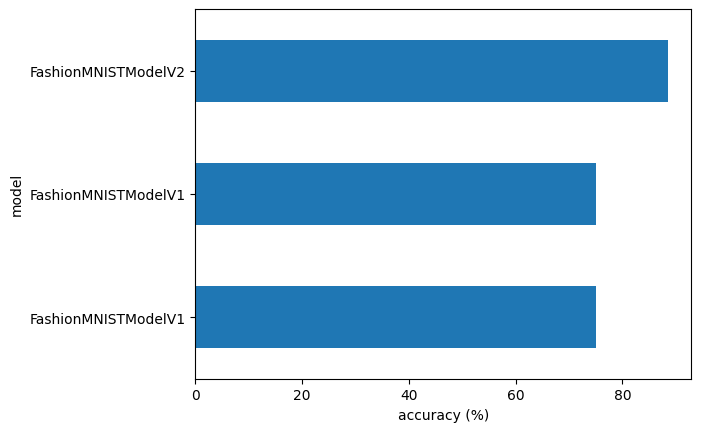

In [39]:
#Визуализируйте результаты нашей модели
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")


## 9. Делайте и оценивайте случайные прогнозы с помощью лучшей модели

Хорошо, мы сравнили наши модели друг с другом, давайте оценим нашу самую эффективную модель «model_2».

Для этого давайте создадим функцию make_predictions(), куда мы сможем передать модель и некоторые данные для прогнозирования.


In [40]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            #Подготовить образец
            sample = torch.unsqueeze(sample, dim=0).to(device) #Добавьте дополнительное измерение и отправьте образец на устройство

            #Прямой проход (модель выводит необработанный логит)
            pred_logit = model(sample)

            #Получить вероятность прогноза (логит -> вероятность прогноза)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) #примечание: выполните softmax для измерения «logits», а не для измерения «batch» (в данном случае размер пакета равен 1, поэтому мы можем выполнять его для dim=0)

            #Снимите pred_prob с графического процессора для дальнейших вычислений.
            pred_probs.append(pred_prob.cpu())

    #Сложите pred_probs, чтобы превратить список в тензор
    return torch.stack(pred_probs)


In [41]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

#Просмотр формы и этикетки первого тестового образца
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")


Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [42]:
#Делайте прогнозы на тестовых образцах с помощью модели 2.
pred_probs= make_predictions(model=model2,
                             data=test_samples)

#Посмотреть список вероятностей первых двух прогнозов
pred_probs[:2]


tensor([[1.9443e-06, 1.9443e-06, 1.9443e-06, 1.9443e-06, 1.9443e-06, 9.1261e-01,
         1.9443e-06, 6.5332e-03, 3.0712e-06, 8.0841e-02],
        [1.0257e-01, 9.9714e-02, 9.9714e-02, 9.9714e-02, 9.9714e-02, 9.9714e-02,
         9.9714e-02, 9.9714e-02, 9.9714e-02, 9.9714e-02]])

И теперь мы можем использовать нашу функцию make_predictions() для прогнозирования на test_samples.


In [43]:
#Делайте прогнозы на тестовых образцах с помощью модели 3.
pred_probs= make_predictions(model=model3,
                             data=test_samples)

#Посмотреть список вероятностей первых двух прогнозов
pred_probs[:2]


tensor([[2.8692e-08, 2.1954e-08, 2.5527e-08, 1.4985e-08, 8.8497e-09, 9.9970e-01,
         1.8319e-07, 1.3354e-06, 9.1697e-06, 2.8869e-04],
        [2.8304e-02, 6.9868e-01, 1.6685e-03, 1.1444e-01, 7.2803e-02, 5.8137e-05,
         8.3020e-02, 8.2878e-05, 6.6485e-04, 2.8134e-04]])

Отличный!

И теперь мы можем перейти от вероятностей прогнозирования к меткам прогнозирования, взяв `torch.argmax()` из выходных данных функции активации `torch.softmax()`.


In [44]:
#Превратите вероятности прогнозирования в метки прогнозирования, взяв argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes


tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [45]:
#Являются ли наши прогнозы в той же форме, что и наши тестовые метки?
test_labels, pred_classes


([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

Теперь наши прогнозируемые классы имеют тот же формат, что и наши тестовые метки, и мы можем сравнивать их.

Поскольку мы имеем дело с данными изображений, давайте останемся верными девизу исследователя данных.

«Визуализируй, визуализируй, визуализируй!»


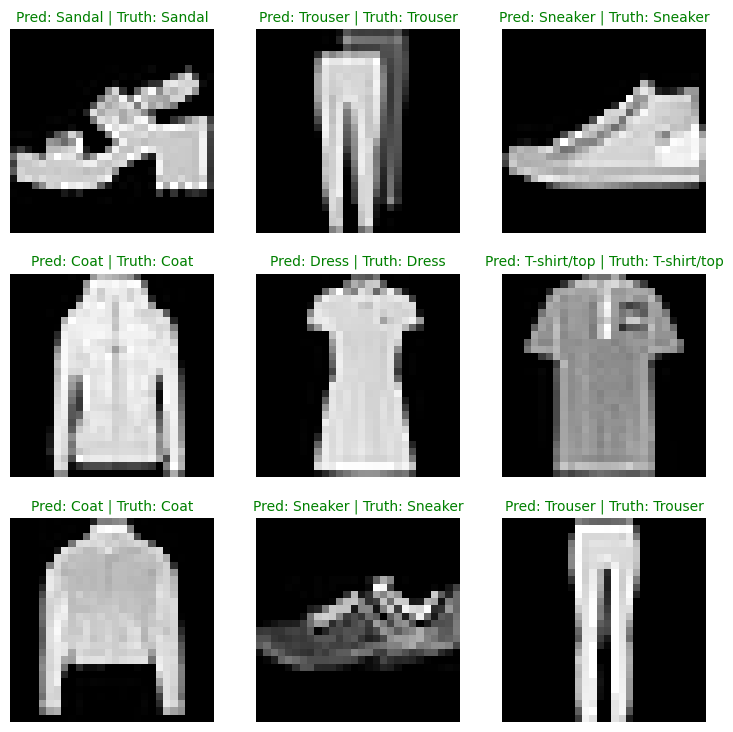

In [46]:
#График предсказаний
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  #Создать подсюжет
  plt.subplot(nrows, ncols, i+1)

  #Постройте целевое изображение
  plt.imshow(sample.squeeze(), cmap="gray")

  #Найдите метку предсказания (в текстовой форме, например «Сандалии»).
  pred_label = class_names[pred_classes[i]]

  #Получите метку правды (в текстовой форме, например, «Футболка»)
  truth_label = class_names[test_labels[i]]

  #Создайте текст заголовка сюжета
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  #Проверьте равенство и соответствующим образом измените цвет заголовка.
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") #зеленый текст, если правильно
  else:
      plt.title(title_text, fontsize=10, c="r") #красный текст, если ошибаюсь
  plt.axis(False)


Ну, ну, ну, разве это не хорошо выглядит!

Неплохо для пары десятков строк кода PyTorch!


## 10. Составление матрицы путаницы для дальнейшей оценки прогноза

Существует множество [различных показателей оценки](https://www.learnpytorch.io/02_pytorch_classification/#9-more-classification-evaluation-metrics), которые мы можем использовать для решения задач классификации.

Одним из наиболее наглядных является [матрица путаницы](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/).

Матрица путаницы показывает, где в вашей модели классификации произошла путаница между предсказаниями и истинными метками.

Чтобы составить матрицу путаницы, мы проделаем три шага:
1. Сделайте прогнозы с помощью нашей обученной модели «model_2» (матрица путаницы сравнивает прогнозы с истинными метками).
2. Создайте матрицу путаницы, используя [`torchmetrics.ConfusionMatrix`](https://torchmetrics.readthedocs.io/en/latest/references/modules.html?highlight=confusion#confusionmatrix).
3. Постройте матрицу путаницы, используя [`mlxtend.plotting.plot_confusion_matrix()`](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_confusion_matrix/).

Давайте начнем с прогнозирования с помощью нашей обученной модели.


In [47]:
#Импортировать tqdm для индикатора выполнения
from tqdm.auto import tqdm

#1. Делайте прогнозы с помощью обученной модели
y_preds = []
model3.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    #Отправка данных и целей на целевое устройство
    X, y = X.to(device), y.to(device)
    #Сделайте пас вперед
    y_logit = model3(X)
    #Превратите прогнозы из логитов -> вероятности прогнозов -> метки прогнозов
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) #примечание: выполните softmax для измерения «logits», а не для измерения «batch» (в данном случае размер пакета равен 32, поэтому мы можем выполнить его для dim=1)
    #Поместите прогнозы в ЦП для оценки
    y_preds.append(y_pred.cpu())
#Объединить список прогнозов в тензор
y_pred_tensor = torch.cat(y_preds)


Making predictions: 100%|██████████| 313/313 [00:01<00:00, 175.38it/s]


Теперь у нас есть прогнозы, давайте пройдем шаги 2 и 3:
2. Создайте матрицу путаницы, используя [`torchmetrics.ConfusionMatrix`](https://torchmetrics.readthedocs.io/en/latest/references/modules.html?highlight=confusion#confusionmatrix).
3. Постройте матрицу путаницы, используя [`mlxtend.plotting.plot_confusion_matrix()`](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_confusion_matrix/).

Сначала нам нужно убедиться, что у нас установлены «torchmetrics» и «mlxtend» (эти две библиотеки помогут нам составить и визуализировать матрицу путаницы).

> **Примечание.** Если вы используете Google Colab, по умолчанию установлена ​​версия mlxtend — 0.14.0 (по состоянию на март 2022 г.), однако для параметров функцииplot_confusion_matrix(), которую мы хотели бы использовать, нам нужна версия 0.19.0 или выше.


Чтобы построить матрицу путаницы, нам нужно убедиться, что у нас есть [`mlxtend`](http://rasbt.github.io/mlxtend/) версии 0.19.0 или выше.


In [48]:
#Импортировать обновленную версию mlxtend
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 #должна быть версия 0.19.0 или выше


0.24.0


«torchmetrics» и «mlxtend» установлены, давайте составим матрицу путаницы!

Сначала мы создадим экземпляр torchmetrics.ConfusionMatrix, сообщающий ему, со сколькими классами мы имеем дело, установив `num_classes=len(class_names)`.

Затем мы создадим матрицу путаницы (в тензорном формате), передав нашему экземпляру прогнозы нашей модели (`preds=y_pred_tensor`) и цели (`target=test_data.targets`).

Наконец, мы можем построить нашу матрицу конфигурации, используя функциюplot_confusion_matrix() изmlxtend.plotting.


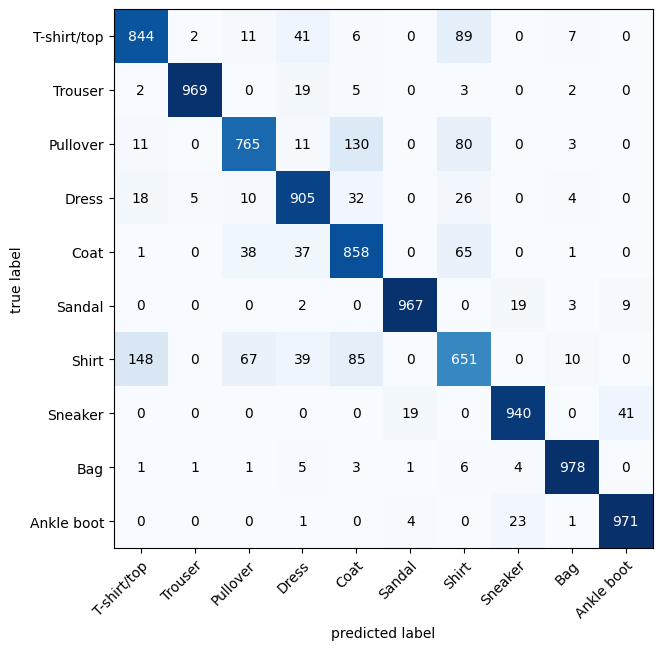

In [49]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

#2. Настройте экземпляр матрицы путаницы и сравните прогнозы с целевыми значениями.
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

#3. Постройте матрицу путаницы
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), #matplotlib любит работать с NumPy
    class_names=class_names, #превратить метки строк и столбцов в имена классов
    figsize=(10, 7)
)


Мы видим, что наша модель работает довольно хорошо, поскольку большинство темных квадратов расположены по диагонали сверху слева вниз справа (и идеальная модель будет иметь значения только в этих квадратах и ​​0 везде).

Модель больше всего «запутывается» на схожих классах, например, прогнозируя «Пуловер» для изображений, которые на самом деле помечены как «Рубашка».

То же самое касается прогнозирования «Рубашки» для классов, которые на самом деле помечены как «Футболка/топ».

Такая информация часто более полезна, чем один показатель точности, поскольку она говорит нам, *где* модель ошибается.

Это также намекает на то, *почему* модель может ошибаться в некоторых вещах.

Понятно, что модель иногда предсказывает «Рубашку» для изображений с надписью «Футболка/топ».

Мы можем использовать такого рода информацию для дальнейшего изучения наших моделей и данных, чтобы понять, как их можно улучшить.

> **Упражнение:** Используйте обученную модель 3 для прогнозирования тестового набора данных FashionMNIST. Затем постройте несколько прогнозов, в которых модель была ошибочной, рядом с тем, какой должна была быть метка изображения. После визуализации этих прогнозов вы думаете, что это скорее ошибка моделирования или ошибка данных? Например, может ли модель работать лучше или метки данных слишком близки друг к другу (например, метка «Рубашка» слишком близка к «Футболка/топ»)?


## 11. Сохраните и загрузите наиболее эффективную модель.

Давайте завершим этот раздел, сохранив и загрузив нашу самую производительную модель.

Напомним, из прошлого лабораторного занятия мы можем сохранить и загрузить модель PyTorch, используя комбинацию:
* `torch.save` — функция для сохранения всей модели PyTorch или `state_dict()` модели.
* `torch.load` — функция для загрузки в сохраненный объект PyTorch.
* `torch.nn.Module.load_state_dict()` — функция для загрузки сохраненного `state_dict()` в существующий экземпляр модели.

А пока давайте сохраним `state_dict()` нашей модели3, затем загрузим его обратно и оценим, чтобы убедиться, что сохранение и загрузка прошли правильно.


In [50]:
from pathlib import Path

#Создайте каталог моделей (если он еще не существует), см. https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir.
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, #при необходимости создайте родительские каталоги
                 exist_ok=True #если каталог моделей уже существует, не допускайте ошибок
)

#Создать путь сохранения модели
MODEL_NAME = "model3.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#Сохраните словарь состояния модели.
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model3.state_dict(), #только сохранение state_dict() сохраняет только изученные параметры
           f=MODEL_SAVE_PATH)


Saving model to: models\model3.pth


Теперь у нас есть сохраненная модель `state_dict()`, и мы можем загрузить ее обратно, используя комбинацию `load_state_dict()` и `torch.load()`.

Поскольку мы используем `load_state_dict()`, нам нужно будет создать новый экземпляр `FashionMNISTModelV2()` с теми же входными параметрами, что и наша сохраненная модель `state_dict()`.


In [51]:
#Создайте новый экземпляр FashionMNISTModelV2 (тот же класс, что и сохраненный нами state_dict()).
#Примечание. При загрузке модели произойдет ошибка, если фигуры здесь не будут такими же, как в сохраненной версии.
loaded_model3 = FashionMNISTModelV2(input_shape=1,
                                    hidden_units=10, #попробуйте изменить это на 128 и посмотрите, что произойдет
                                    output_shape=10)

#Загрузите сохраненный state_dict().
loaded_model3.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

#Отправить модель в графический процессор
loaded_model3 = loaded_model3.to(device)


И теперь у нас есть загруженная модель, которую мы можем оценить с помощью `eval_model()`, чтобы убедиться, что ее параметры работают аналогично `model3` перед сохранением.


In [52]:
#Оценить загруженную модель
torch.manual_seed(42)

loaded_model3_results = eval_model(
    model=loaded_model3,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model3_results


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3159361183643341,
 'model_acc': 88.49840255591054}

Эти результаты выглядят так же, как «model3_results»?


In [53]:
model3_results


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3159361183643341,
 'model_acc': 88.49840255591054}

Мы можем узнать, близки ли два тензора друг к другу, используя torch.isclose() и передавая уровень допуска близости через параметры atol (абсолютный допуск) и rtol (относительный допуск).

Если результаты нашей модели близки, вывод torch.isclose() должен быть истинным.


In [54]:
#Проверьте, близки ли результаты друг к другу (если они очень далеко, возможно, возникла ошибка)
torch.isclose(torch.tensor(model3_results["model_loss"]),
              torch.tensor(loaded_model3_results["model_loss"]),
              atol=1e-08, #абсолютная толерантность
              rtol=0.0001) #относительная толерантность


tensor(True)

## Упражнения

Все упражнения направлены на отработку кода, описанного в разделах выше.

Вы должны быть в состоянии заполнить их, ссылаясь на каждый раздел или перейдя по связанному ресурсу(ам).

Все упражнения следует выполнять с использованием [кода, не зависящего от устройства] (https://pytorch.org/docs/stable/notes/cuda.html#device-agnostic-code).


1. Визуализируйте как минимум 5 различных образцов набора обучающих данных MNIST.
2. Превратите обучающие и тестовые наборы данных MNIST в загрузчики данных с помощью torch.utils.data.DataLoader, установите параметр batch_size=32.
3. Воссоздайте `model_2`, используемую в этом блокноте (та же модель с [веб-сайта CNN объяснения] (https://poloclub.github.io/cnn-explainer/), также известную как TinyVGG), способную вписаться в набор данных MNIST.
4. Обучите модель, построенную в упражнении 8, на процессоре и графическом процессоре и посмотрите, сколько времени это займет на каждом из них.
5. Сделайте прогнозы, используя обученную модель, и визуализируйте как минимум 5 из них, сравнивая прогноз с целевой меткой.
6. Постройте матрицу путаницы, сравнивая предсказания вашей модели с метками истинности.
7. Используйте модель, аналогичную обученной модели_2 из этого блокнота, чтобы сделать прогнозы для тестового набора данных [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html).
    * Затем постройте несколько прогнозов, в которых модель была ошибочной, рядом с тем, какой должна была быть метка изображения.
    * После визуализации этих прогнозов вы думаете, что это скорее ошибка моделирования или ошибка данных?
    * Например, может ли модель работать лучше или метки данных слишком близки друг к другу (например, метка «Рубашка» слишком близка к «Футболка/топ»)?
